In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

plt.rcParams["figure.figsize"] = (8, 4.5)
print("Ready to go")

Ready to go


# **Part A — Hierarchical clustering**
## **TASK 01 — Read a dendrogram**

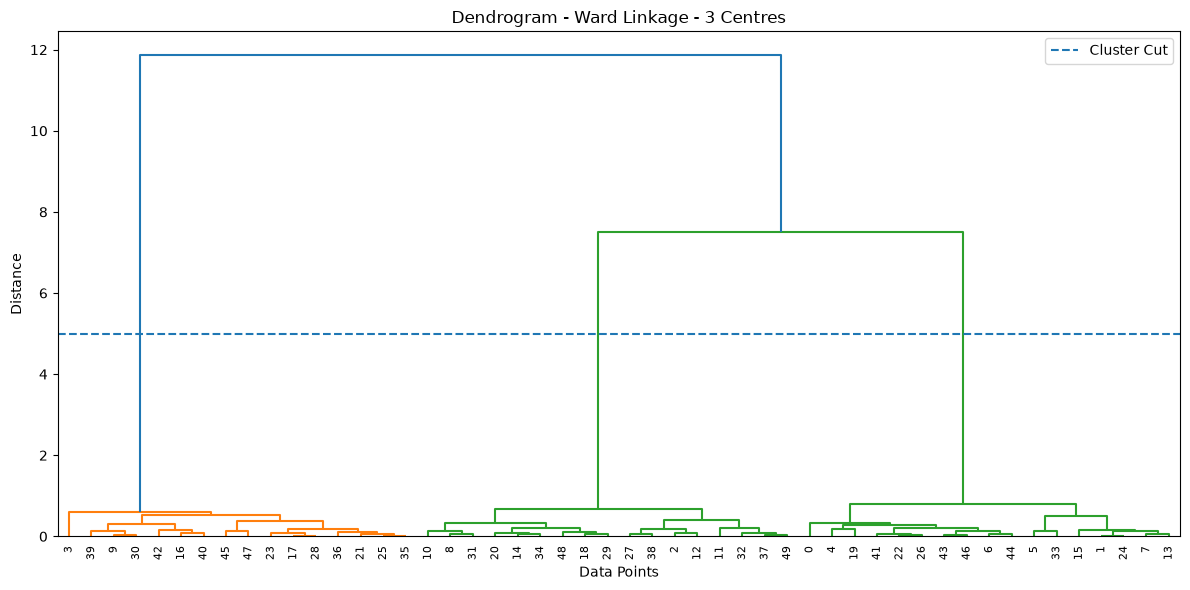

In [46]:
from sklearn.datasets import make_blobs, make_moons, make_circles


# for 3 centres
X_blobs, y_blobs = make_blobs(n_samples=50, centers=3, cluster_std=0.8, random_state=42)
X_scaled = StandardScaler().fit_transform(X_blobs)    # Scale the data

# Ward linkage 
Z = linkage(X_scaled, method="ward")

# plot dendrogram
fig, ax = plt.subplots(figsize=(12, 6))

dendrogram(Z)

ax.set_title("Dendrogram - Ward Linkage - 3 Centres")
ax.set_xlabel("Data Points"); ax.set_ylabel("Distance")
ax.axhline(y=5, ls="--", label="Cluster Cut")
ax.legend()
plt.tight_layout()
plt.show()

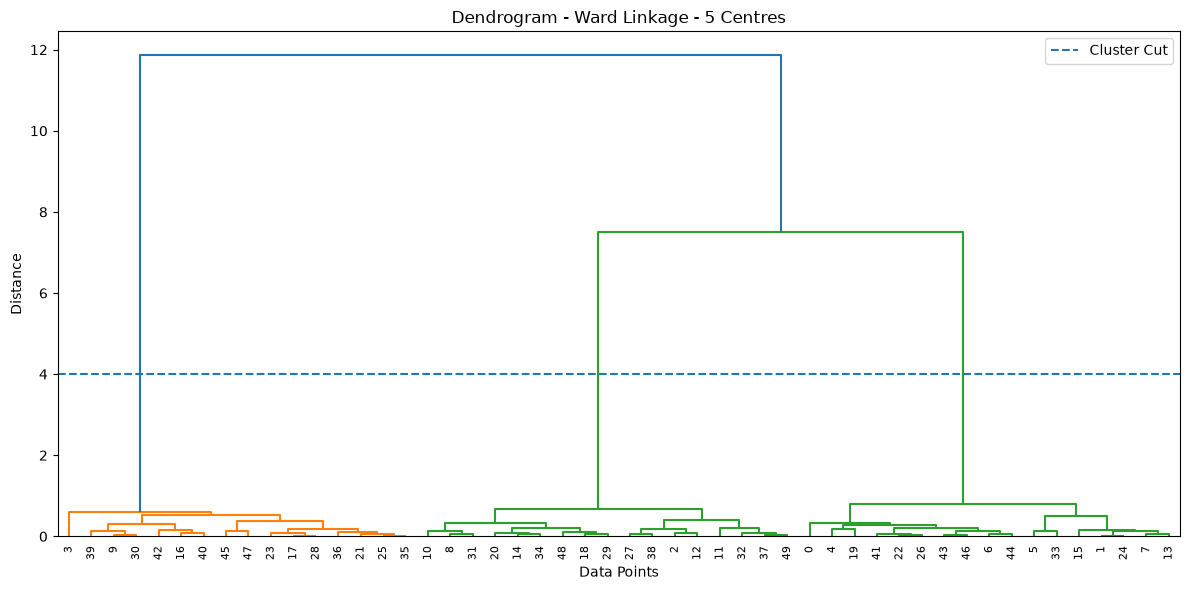

In [47]:
# For 5 centres
X_5, y_5 = make_blobs(n_samples=50, centers=5, cluster_std=0.8, random_state=42)
X_5_scaled = StandardScaler().fit_transform(X_5)

# Ward Linkage
Z_5 = linkage(X_5_scaled, method="ward")

# Plot Dendrogram
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z)

ax.set_title("Dendrogram - Ward Linkage - 5 Centres")
ax.set_xlabel("Data Points"); ax.set_ylabel("Distance")
ax.axhline(y=4, ls="--", label="Cluster Cut")
ax.legend()
plt.tight_layout()
plt.show()

* A long vertical branch indicates that two groups are being joined at a relatively large distance. This suggests that the groups are well separated.
* For data with no clear clusters, the dendrogram would not show strong, distinct jumps between groups.

## **TASK 02 — Compare the four linkage rules**

In [48]:
# Create Data sets

# blobs
X_blobs, y_blobs = make_blobs(n_samples=500, centers=3, cluster_std=0.8, random_state=42)

# Moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=42)

# Circles
X_circles, y_circles = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Stretched blobs
X_stretched, y_stretched = make_blobs(n_samples=500, centers=3, cluster_std=0.7, random_state=42)
X_stretched[:, 0] = X_stretched[:, 0] * 4


# Scale datasets
X_blobs = StandardScaler().fit_transform(X_blobs)
X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

datasets = {
    "Blobs": (X_blobs, y_blobs),
    "Moons": (X_moons, y_moons),
    "Circles": (X_circles, y_circles),
    "Stretched Blobs": (X_stretched, y_stretched)
}

linkages = [
    "single", "complete", "average", "ward"
]

results = []

for dataset_name, (X_data, y_true) in datasets.items():
    for linkage_method in linkages:
        model = AgglomerativeClustering(
            n_clusters=2 if dataset_name != "Blobs" else 3,
            linkage=linkage_method
        ).fit_predict(X_data)

        ari = adjusted_rand_score(y_true, model)

        results.append({
            "Dataset": dataset_name,
            "Linkage": linkage_method,
            "ARI": ari
        })


linkage_results = pd.DataFrame(results)

linkage_results

,Dataset,Linkage,ARI
0,Blobs,single,1.000000
1,Blobs,complete,1.000000
2,Blobs,average,1.000000
3,Blobs,ward,1.000000
4,Moons,single,1.000000
5,Moons,complete,0.626548
6,Moons,average,0.626548
7,Moons,ward,0.626548
8,Circles,single,1.000000
9,Circles,complete,-0.001938


In [49]:
# Make one table 
linkage_table = linkage_results.pivot(
    index="Dataset",
    columns="Linkage",
    values="ARI"
)

linkage_table

Linkage,average,complete,single,ward
Dataset,,,,
Blobs,1.000000,1.000000,1.000000,1.000000
Circles,0.010785,-0.001938,1.000000,0.005752
Moons,0.626548,0.626548,1.000000,0.626548
Stretched Blobs,0.571184,0.571184,0.571184,0.571184


* Single linkage measures the distance between two clusters using the closest pair of points, so it can connect points through narrow chains and is able to detect curved shapes. Complete, average and Ward linkage consider broader distances between groups, making them more suitable for compact and well-separated clusters.

## **TASK 03 — Break single linkage**

In [50]:
X_raw = X_blobs.copy()

single_original = AgglomerativeClustering(
    3, linkage="single"
).fit_predict(StandardScaler().fit_transform(X_raw))

ward_original = AgglomerativeClustering(
    3, linkage="ward"
).fit_predict(StandardScaler().fit_transform(X_raw))

print("Single Linkage ARI:", adjusted_rand_score(y_blobs, single_original))
print("Ward Linkage ARI:", adjusted_rand_score(y_blobs, ward_original))

Single Linkage ARI: 1.0
Ward Linkage ARI: 1.0


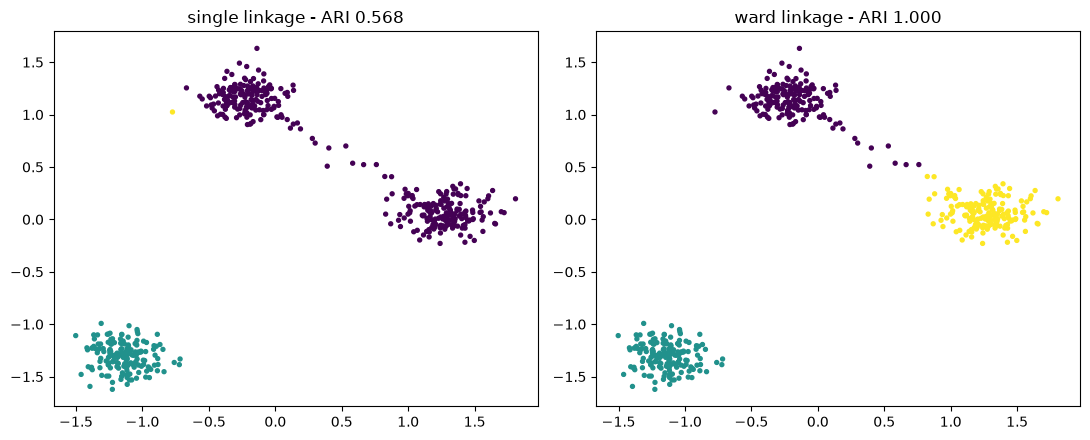

In [51]:
# Add 25-point Bridge
rng = np.random.default_rng(1)
X_raw = X_blobs.copy()

bridge = np.linspace(
    X_raw[y_blobs == 0].mean(0),
    X_raw[y_blobs == 1].mean(0), 25
) + rng.normal(0, 0.05, (25, 2))

X_bridge_raw = np.vstack([
    X_raw, bridge
])

X_bridge = StandardScaler().fit_transform(X_bridge_raw)

real = np.r_[np.ones(len(X_raw), bool), np.zeros(25, bool)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, link in zip(ax, ["single", "ward"]):
    lab = AgglomerativeClustering(3, linkage=link).fit_predict(X_bridge)
    score = adjusted_rand_score(y_blobs, lab[real])
    ax.scatter(X_bridge[:, 0], X_bridge[:, 1], c=lab, cmap="viridis", s=8)
    ax.set_title(f"{link} linkage - ARI {score:.3f}")


plt.tight_layout()
plt.show()

In [52]:
# Bridge Size experiment
bridge_sizes = [10, 25, 50, 100]

single_scores = []

for bridge_size in bridge_sizes:
    rng = np.random.default_rng(1)
    bridge = np.linspace(X_raw[y_blobs == 0].mean(0),
                        X_raw[y_blobs == 1].mean(0), bridge_size)
    bridge = bridge + rng.normal(0, 0.05, (bridge_size, 2))
    X_temp = np.vstack([X_raw, bridge])
    X_temp = StandardScaler().fit_transform(X_temp)
    labels = AgglomerativeClustering(3, linkage="single").fit_predict(X_temp)

    ari = adjusted_rand_score(y_blobs, labels[:len(y_blobs)])

    single_scores.append(ari)

bridge_results = pd.DataFrame({
    "Bridge Size": bridge_sizes,
    "Single Linkage ARI": single_scores
})

print(bridge_results.to_string(index=False))

 Bridge Size  Single Linkage ARI
          10            1.000000
          25            0.568243
          50            0.568243
         100            0.568243


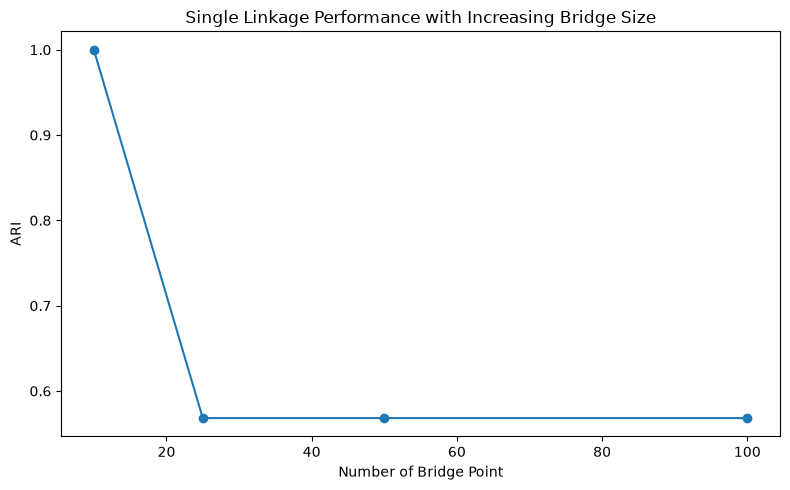

In [53]:
# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bridge_sizes, single_scores, marker="o")
ax.set_title("Single Linkage Performance with Increasing Bridge Size")
ax.set_xlabel("Number of Bridge Point")
ax.set_ylabel("ARI")

plt.tight_layout()
plt.show()

* This failure is called the chaining effect.
* Single linkage only needsone close pair of points to connect two groups, so a thin bridge can cause two otherwise separate clusters to be merged.
* Real data containing continuous paths, narrow transitions or connected noise can be vulnerable to this problem.

# **Part B — DBSCAN**
## **TASK 04 — Find the eps sweet spot**

In [54]:
X, y = datasets["Moons"]
eps_values = np.arange(0.05, 1.01, 0.05)
eps_results = []

for eps in eps_values:
    lab = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())
    ari = adjusted_rand_score(y, lab)

    eps_results.append({
        "eps": eps, "clusters": n_clusters,
        "noise points": n_noise, "ARI": ari
    })

eps_df = pd.DataFrame(eps_results)

print(eps_df.to_string(index=False))

 eps  clusters  noise points      ARI
0.05         3           482 0.000663
0.10        27           132 0.061374
0.15         4            23 0.793134
0.20         2             4 0.984080
0.25         2             0 1.000000
0.30         2             0 1.000000
0.35         2             0 1.000000
0.40         2             0 1.000000
0.45         1             0 0.000000
0.50         1             0 0.000000
0.55         1             0 0.000000
0.60         1             0 0.000000
0.65         1             0 0.000000
0.70         1             0 0.000000
0.75         1             0 0.000000
0.80         1             0 0.000000
0.85         1             0 0.000000
0.90         1             0 0.000000
0.95         1             0 0.000000
1.00         1             0 0.000000


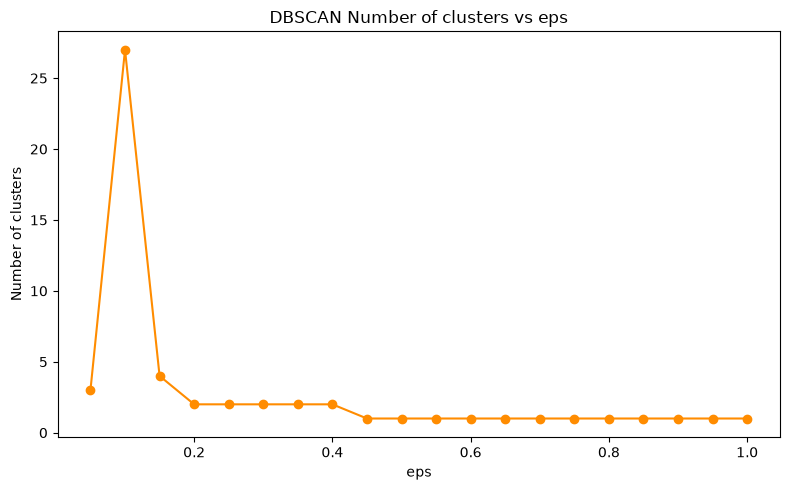

In [55]:
# Number of clusters VS eps
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(eps_df["eps"], eps_df["clusters"], marker="o", color="darkorange")
ax.set_title("DBSCAN Number of clusters vs eps")
ax.set_xlabel("eps")
ax.set_ylabel("Number of clusters")
plt.tight_layout()
plt.show()

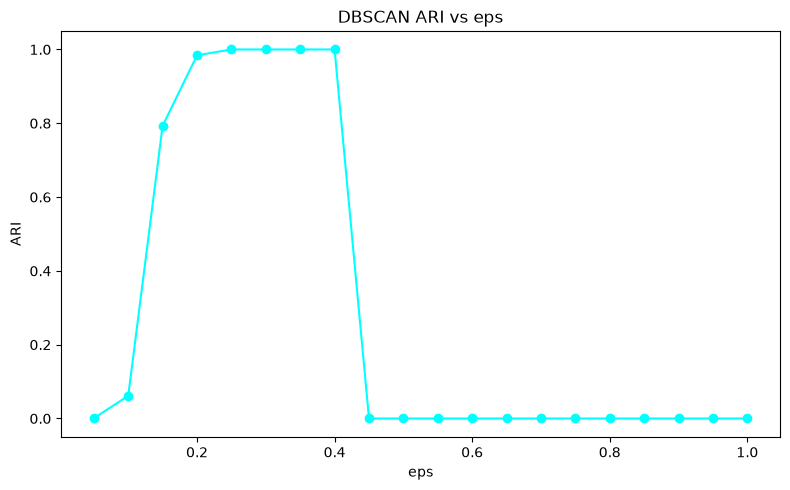

In [56]:
# ARI vs eps
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_df["eps"], eps_df["ARI"], marker="o", color="cyan")
ax.set_title("DBSCAN ARI vs eps")
ax.set_xlabel("eps")
ax.set_ylabel("ARI")
plt.tight_layout()
plt.show()

In [57]:
# Find best eps
best_eps_row = eps_df.loc[eps_df["ARI"].idxmax()]

print("Best eps:", best_eps_row["eps"])
print("Best ARI:", best_eps_row["ARI"])

Best eps: 0.25
Best ARI: 1.0


* When eps is too small, points do not have enough neighbours to form stable dense regions, so many observations become noise or small clusters.
* When eps becomes too large, separate dense regions can be connected, causing different clusters to merge.
* The useful eps range should be identified from the actual table and ARI plot above.

## **TASK 05 — Choose eps without knowing the answer**

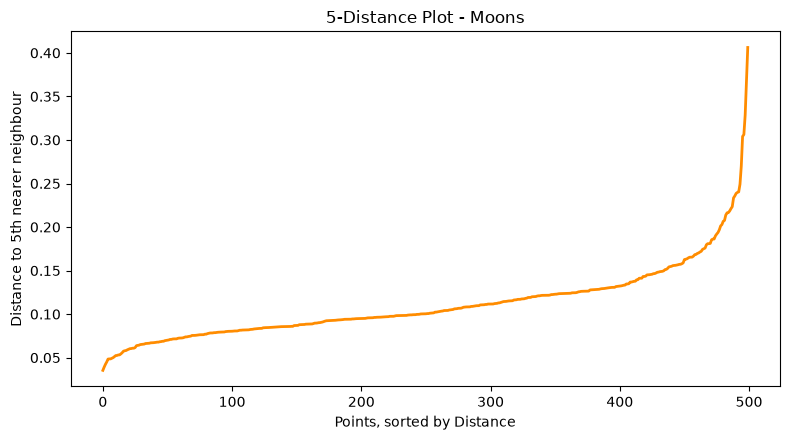

In [58]:
from sklearn.neighbors import NearestNeighbors

X_moons, y_moons = datasets["Moons"]

k = 5
neighbors = NearestNeighbors(n_neighbors=k).fit(X_moons)
distances, indices = neighbors.kneighbors(X_moons)
k_distances = np.sort(distances[:, k - 1])

fig, ax = plt.subplots()
ax.plot(k_distances, color="darkorange", lw=2)
ax.set_xlabel("Points, sorted by Distance")
ax.set_ylabel("Distance to 5th nearer neighbour")
ax.set_title("5-Distance Plot - Moons")

plt.tight_layout()
plt.show()

In [59]:
# Choose eps before checking ARI
choosen_eps_moons = 0.20

# Run DBSCAN
moon_labels = DBSCAN(eps=choosen_eps_moons, min_samples=5).fit_predict(X_moons)
moon_ari = adjusted_rand_score(y_moons, moon_labels)

print("Choosen eps:", choosen_eps_moons)
print("ARI:", round(moon_ari, 4))

Choosen eps: 0.2
ARI: 0.9841


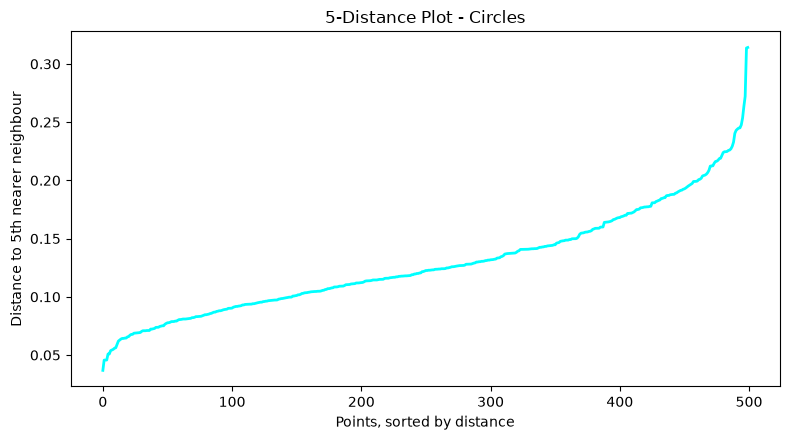

In [60]:
# With Circles
X_circles, y_circles = datasets["Circles"]

neighbors = NearestNeighbors(n_neighbors=5).fit(X_circles)
distances, indices = neighbors.kneighbors(X_circles)
k_distances = np.sort(distances[:, 4])

fig, ax = plt.subplots()
ax.plot(k_distances, color="cyan", lw=2)
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel("Distance to 5th nearer neighbour")
ax.set_title("5-Distance Plot - Circles")

plt.tight_layout()
plt.show()

In [61]:
# choosen eps 
choosen_eps_circles = 0.20

# RUN DBSCAN
circle_labels = DBSCAN(eps=choosen_eps_circles, min_samples=5).fit_predict(X_circles)
circle_ari = adjusted_rand_score(y_circles, circle_labels)

print("Choosen eps:", choosen_eps_circles)
print(f"ARI: {circle_ari:.3f}")

Choosen eps: 0.2
ARI: 0.680


**Conclusion -->**
* The k-distance method gives a practical way to select eps without using the true labels. Its selected value should be compared with the best eps found in Task 04 to see how close the visual estimate was.
* This makes k-distance useful when there is no answer key, although the bend can be subjective and should be checked against the resulting clusters and business meaning.

# **Part C — GMM and the bake-off**
## **TASK 06 — Soft clustering**

In [62]:
X, y = make_blobs(n_samples=600, centers=[[-2, 0], [0, 0], [2, 0]], 
                  cluster_std=1.1, random_state=0)
X = StandardScaler().fit_transform(X)

# Fit GMM
gmm = GaussianMixture(3, covariance_type="full", random_state=0).fit(X)
probabilities = gmm.predict_proba(X)
confidence = probabilities.max(axis=1)
uncertain = confidence < 0.6

print("Number of uncertain points:", int(uncertain.sum()))

Number of uncertain points: 101


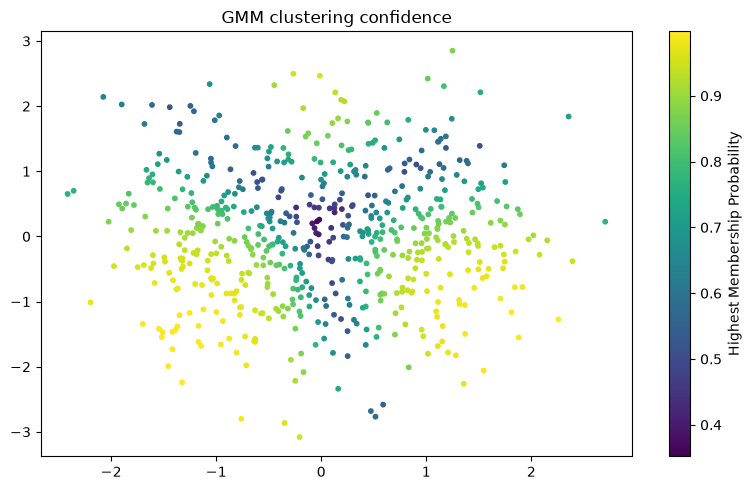

In [63]:
# Confidence Plot
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X[:, 0], X[:, 1], c=confidence, cmap="viridis", s=10)
fig.colorbar(scatter, ax=ax, label="Highest Membership Probability")
ax.set_title("GMM clustering confidence")
plt.tight_layout()
plt.show()

* The uncertain points are mainly located near the boundaries where clusters overlap. GMM gives these points similar probabilities for multiple groups because their position does not strongly favour only one cluster.
* In a real customer-marketing situation, an uncertain customer could receive a general campaign or be reviewed separately instead of being automatically assigned to a highly specific segment.

## **TASK 07 — Run the full bake-off**

In [64]:
def run_all(X, k):
    return{
        "k-means": KMeans(k, n_init=10, random_state=0).fit_predict(X),
        "ward": AgglomerativeClustering(k, linkage="ward").fit_predict(X),
        "single": AgglomerativeClustering(k, linkage="single").fit_predict(X),
        "DBSCAN (eps=0.2)": DBSCAN(eps=0.2, min_samples=5).fit_predict(X),
        "GMM": GaussianMixture(k, covariance_type="full", random_state=0).fit_predict(X)
    }


scores = {}
for name, (X, y) in datasets.items():
    k = len(np.unique(y))
    scores[name] = {method: adjusted_rand_score(y, labels) for method, labels in run_all(X, k).items()}

table = pd.DataFrame(scores).T.round(3)
print(table.to_string())

                 k-means   ward  single  DBSCAN (eps=0.2)    GMM
Blobs              1.000  1.000     1.0             0.997  1.000
Moons              0.445  0.627     1.0             0.984  0.461
Circles           -0.002  0.006     1.0             0.680 -0.002
Stretched Blobs    1.000  1.000     1.0             0.001  1.000


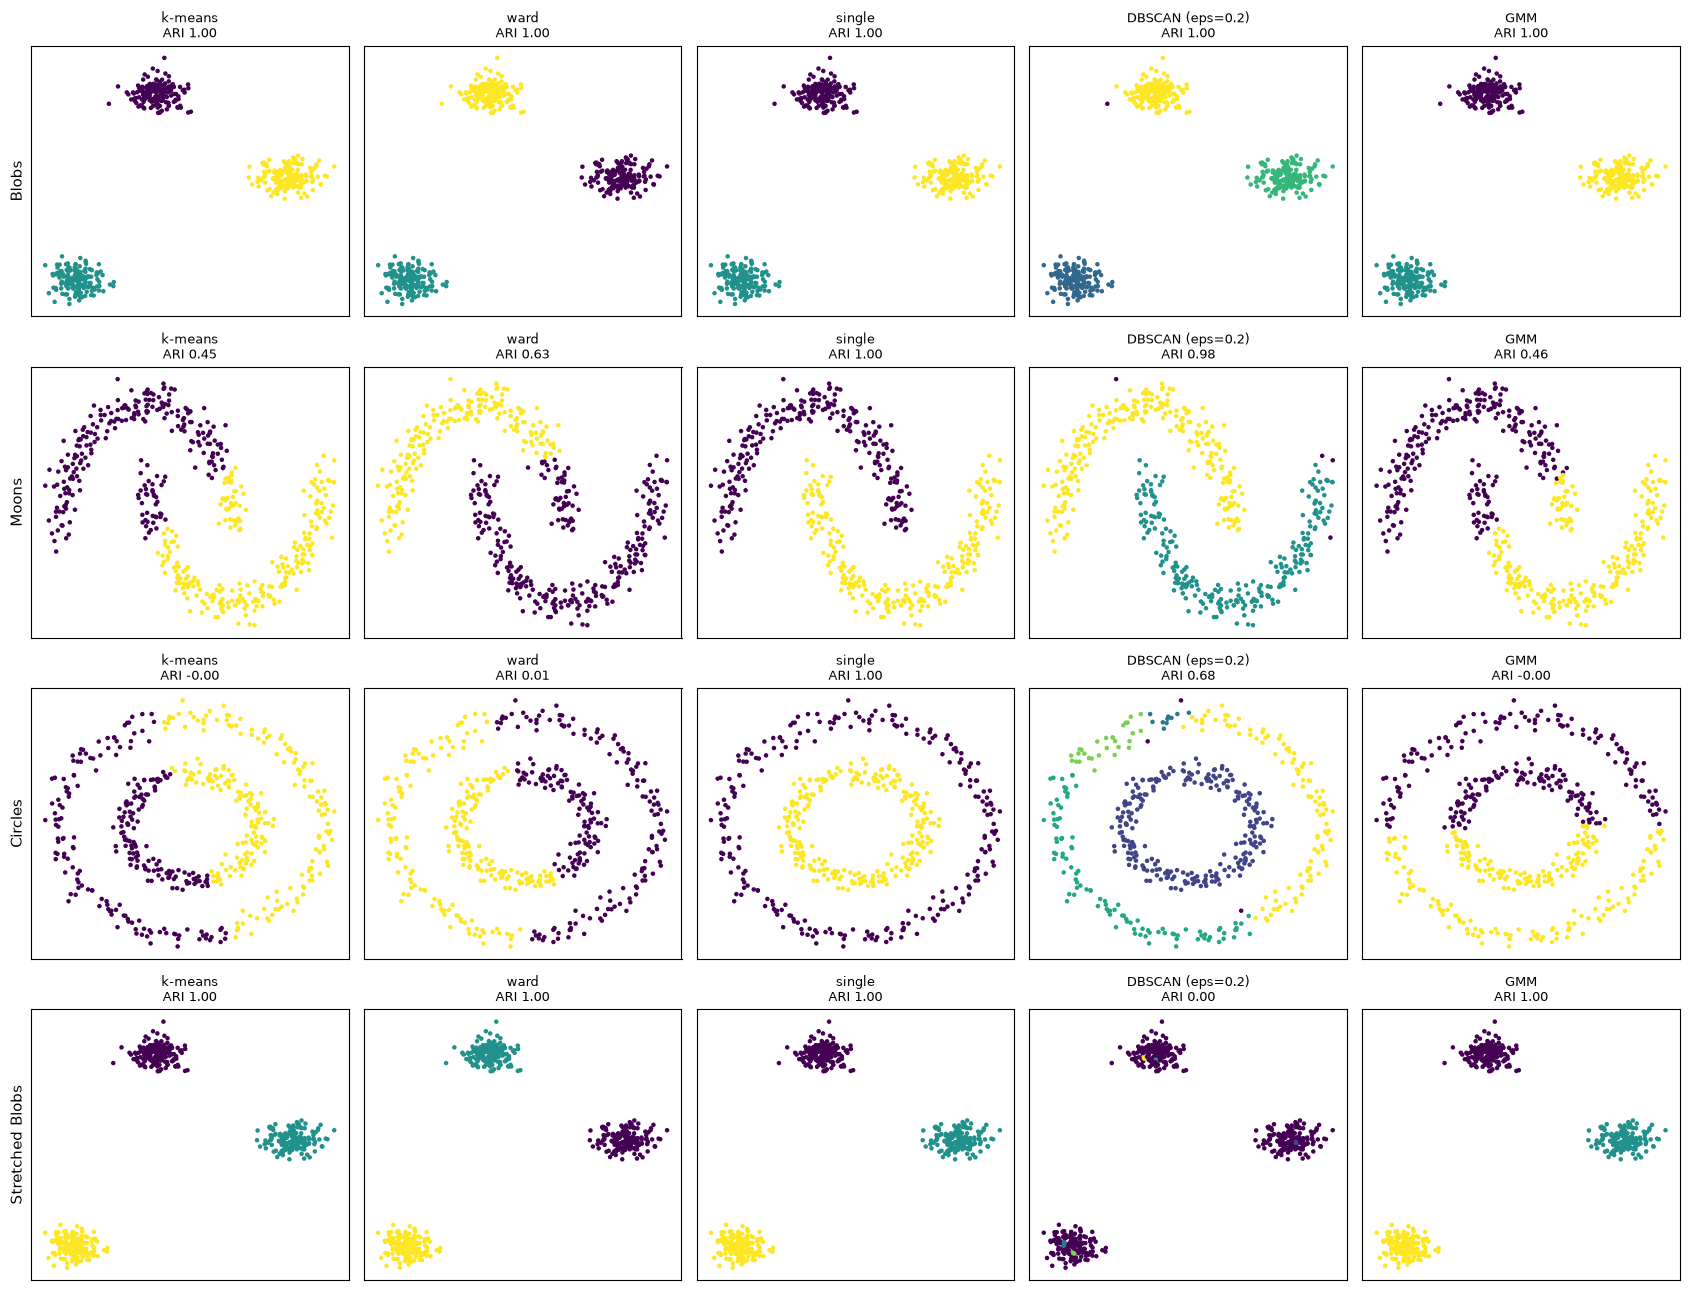

In [65]:
# Plot grid
fig, axes = plt.subplots(4, 5, figsize=(17, 13))
for row, (name, (X, y)) in enumerate(datasets.items()):
    k = len(np.unique(y))
    for col, (method, lab) in enumerate(run_all(X, k).items()):
        ax = axes[row, col]
        ax.scatter(X[:, 0], X[:, 1], c=lab, cmap="viridis", s=5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{method}\nARI {adjusted_rand_score(y, lab):.2f}", fontsize=9)
        if col == 0:
            ax.set_ylabel(name, fontsize=11)

plt.tight_layout()
plt.show()

In [66]:
# find the best method for each shape
winner_rows = []
for dataset_name in table.index:
    winner = table.loc[dataset_name].idxmax()
    score = table.loc[dataset_name, winner]
    winner_rows.append({
        "Dataset": dataset_name,
        "Method": winner,
        "ARI": score
    })

winner_df = pd.DataFrame(winner_rows)
print(winner_df.to_string(index=False))

        Dataset  Method  ARI
          Blobs k-means  1.0
          Moons  single  1.0
        Circles  single  1.0
Stretched Blobs k-means  1.0


* There is no single best clustering method across all four shapes. The ARI table shows that the method that performs well depends on the
structure of the data. Compact blobs can be handled by methods such as k-means and Ward, curved structures favour methods based on connectivity or density such as single linkage and DBSCAN, while stretched clusters can favour GMM because it can model different cluster shapes.
* DBSCAN is kept at the same eps=0.2 for every dataset in this bake-off, so it does not receive a separate tuning advantage for individual shapes.

# **Part D — Real customers**
## **TASK 08 — Three questions, three methods**

In [67]:
# Load customer data
customers = pd.read_csv("customer_rfm.csv")
features = ["recency_days", "frequency", "monetary"]
Xc = StandardScaler().fit_transform(customers[features])
print(len(customers), "Customers")

1500 Customers


**Question 1: fit GMM for K from 2 to 8 and record BIC. Which K does it choose?**

In [71]:
bic_results = []
for k in range(2, 9):
    g = GaussianMixture(k, covariance_type="full", random_state=0, n_init=3).fit(Xc)
    bic_results.append({
        "K": k,
        "BIC": g.bic(Xc)
    })

bic_df = pd.DataFrame(bic_results)
bic_df["BIC"] = bic_df["BIC"].round(1)
print(bic_df.to_string(index=False))

 K    BIC
 2 7462.8
 3 6377.2
 4 5943.1
 5 5588.6
 6 5645.6
 7 5658.7
 8 5724.9


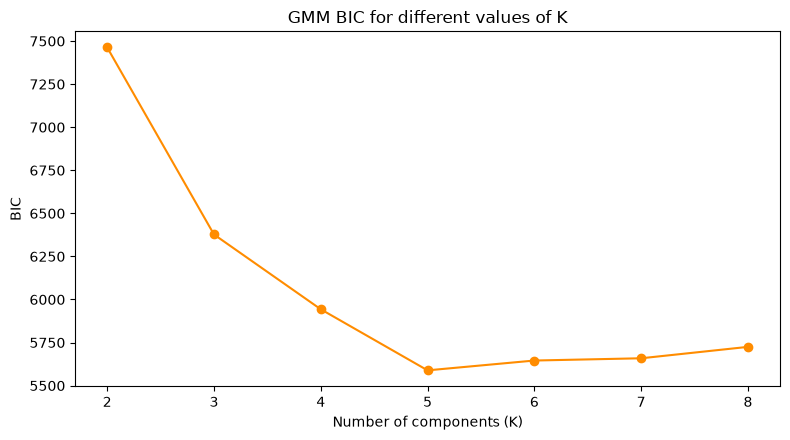

In [73]:
# BIC plot
fig, ax = plt.subplots()

ax.plot(bic_df["K"], bic_df["BIC"], marker="o", color="darkorange")
ax.set_title("GMM BIC for different values of K")
ax.set_xlabel("Number of components (K)")
ax.set_ylabel("BIC")

plt.tight_layout()
plt.show()

In [74]:
# Select K
best_k = int(bic_df.loc[bic_df["BIC"].idxmin(), "K"])

print("GMM selected K:", best_k)
print("Day 31 business K:", 5)

GMM selected K: 5
Day 31 business K: 5


**Question 2: fit GMM at your chosen K and list the customers whose top probability is below 0.6.**

In [75]:
gmm = GaussianMixture(5, covariance_type="full", random_state=0, n_init=3).fit(Xc)
probs = gmm.predict_proba(Xc)
confidence = probs.max(axis=1)

customers["gmm_cluster"] = gmm.predict(Xc)
customers["gmm_confidence"] = confidence

# Count uncertain customers
uncertain_customers = customers[customers["gmm_confidence"] < 0.6].copy()

print("Customers with top probability below 0.6", len(uncertain_customers))

Customers with top probability below 0.6 23


In [77]:
print(
    uncertain_customers[
        [
            "gmm_cluster", "gmm_confidence", "recency_days",
            "frequency", "monetary"
        ]
    ].to_string(index=False)
)

 gmm_cluster  gmm_confidence  recency_days  frequency  monetary
           0        0.527199            10         11  31508.46
           0        0.515191            17         14  22683.42
           1        0.593300           302          2   8837.66
           4        0.505680            18          6  36466.33
           2        0.527866           302          5   6036.29
           4        0.542681            16          6  35899.73
           2        0.564614           352          6    867.98
           0        0.583602            25         14  27354.03
           4        0.504837            29         14   8636.50
           2        0.582103           300          5    464.60
           4        0.549982            41         17  20727.79
           2        0.504436            92          6  28028.98
           4        0.577649            20         13  25664.57
           4        0.523632            67          4  32521.04
           0        0.502019            

In [78]:
# Most ambiguous customer
most_ambiguous = int(np.argmin(confidence))

print("Most Ambiguous Customer:")
print(customers.iloc[most_ambiguous][features].to_dict())
print("\nMembership Probabilities:")
print(np.round(probs[most_ambiguous], 3))

Most Ambiguous Customer:
{'recency_days': 25, 'frequency': 4, 'monetary': 35775.4}

Membership Probabilities:
[0.113 0.    0.001 0.398 0.488]


**Question 3: run DBSCAN and report how many clusters and how many noise points it finds.**

In [81]:
# DBSCAN
dbscan_labels = DBSCAN(eps=0.4, min_samples=5).fit_predict(Xc)
customers["dbscan_cluster"] = (dbscan_labels)

# Number of clusters and noise
n_dbscan_clusters = len(set(dbscan_labels) - {-1})
n_noise = int((dbscan_labels == -1).sum())

print("DBSCAN noise points:")
print(n_noise)

DBSCAN noise points:
16


In [84]:
# For check different eps values
for eps in [0.3, 0.4, 0.5]:
    lab = DBSCAN(eps=eps, min_samples=5).fit_predict(Xc)
    n = len(set(dbscan_labels)) - (1 if -1 in lab else 0)
    noise = int((lab == -1).sum())
    print(f"eps={eps}: {n} cluster(s), {noise} noise points")

eps=0.3: 1 cluster(s), 52 noise points
eps=0.4: 1 cluster(s), 16 noise points
eps=0.5: 1 cluster(s), 8 noise points


In [85]:
# Profile DBSCAN noise
outliers = customers[customers["dbscan_cluster"] == -1]
comparison = pd.DataFrame({
    "flagged customers": outliers[features].mean().round(0),
    "all customers": customers[features].mean().round(0)
})

print(comparison.to_string())

              flagged customers  all customers
recency_days               67.0          209.0
frequency                  13.0            7.0
monetary                68275.0        23671.0


* DBSCAN finds relatively few meaningful clusters in this customer dataset because the RFM population changes gradually rather than forming clearly separated dense islands.
* This makes DBSCAN less suitable for the main customer segmentation task. However, its noise label can still be useful for identifying unusual customers who deserve separate attention.